In [1]:
import torch
import os

print(f"Setup complete. Using torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")

Setup complete. Using torch 2.2.1 (NVIDIA GeForce RTX 3060 Ti)


In [ ]:
from PIL import Image
# # Define path to the image file
source = 'img/case1.jpg'
img = Image.open(source).convert('RGB')
input_img = img.resize((640,640))

# 필요한 라이브러리

In [ ]:
%%capture
# Install PyTorch with CUDA
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install additional dependencies
!pip install matplotlib pandas pillow torchtnt==0.2.0 tqdm tabulate

# Install package for creating visually distinct colormaps
!pip install distinctipy

# Install utility packages
!pip install cjm_pandas_utils cjm_psl_utils cjm_pil_utils cjm_pytorch_utils cjm_torchvision_tfms

# yolo

In [3]:
## 사진이 한장이며, 사진 안의 킥보드도 하나인 상황만을 고려 !!
# -- 첫번째 모델 in, out 구분 
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

In [4]:
model_yolo = YOLO('model/kick_ScooterWheel.pt') 

## 함수

In [5]:
# Run inference on the source
def yolo_run_show(input_img):
    results_yolo = model_yolo(input_img)  # list of Results objects
    results_yolo[0].show()

In [6]:
# Run inference on the source
def yolo_run(input_img):
    results = model_yolo(input_img)  # list of Results objects
    return results[0]

# mask r-cnn

In [8]:
from cjm_pytorch_utils.core import pil_to_tensor, tensor_to_pil, get_torch_device, set_seed, denorm_img_tensor, move_data_to_device

import torch
from torchvision.transforms.functional import to_pil_image
import torchvision.transforms.v2  as transforms
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes

import matplotlib.pyplot as plt

In [9]:
device = get_torch_device()
dtype = torch.float32
device, dtype

('cuda', torch.float32)

In [10]:
model_Mrcnn = torch.load('model/mask r-cnn.pt')

## 함수

In [11]:
def Mrcnn_run_show(device, input_img):
    # Ensure the model and input data are on the same device
    model_Mrcnn.to(device)
    input_tensor = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])(input_img)[None].to(device)
    
    # Make a prediction with the model
    with torch.no_grad():
        model_output = model_Mrcnn(input_tensor)

    # Convert the test images to a tensor
    img_tensor = transforms.PILToTensor()(input_img)
    
    # model_output에서 데이터 추출
    boxes = model_output[0]['boxes']
    labels = model_output[0]['labels']
    scores = model_output[0]['scores']
    masks = model_output[0]['masks']
    
    # labels.unique() 대신 전체 labels를 사용하여 라벨별 색상 매핑을 생성합니다.
    colors = ["blue", "green", "red", "yellow", "purple", "orange"]
    # 모든 라벨에 대해 색상을 지정합니다.
    label_colors = {label.item(): colors[label.item() % len(colors)] for label in labels}
    
    # 세그멘테이션 마스크는 확률값으로 되어 있으므로 이진 마스크로 변환합니다.
    threshold = 0.5
    binary_masks = model_output[0]['masks'] > threshold
    
    # 마스크를 boolean 타입으로 변환합니다.
    binary_masks = binary_masks.squeeze(1).to(torch.bool)
    
    # 라벨별 색상을 마스크와 박스에 적용합니다.
    mask_colors = [label_colors[label.item()] for label in labels]
    box_colors = [label_colors[label.item()] for label in labels]
    
    # 이미지에 세그멘테이션 마스크를 그립니다.
    segmented_img = draw_segmentation_masks(img_tensor, binary_masks, alpha=0.5, colors=mask_colors)
    
    # 이미지에 바운딩 박스와 라벨, 점수를 그립니다.
    annotated_img = draw_bounding_boxes(
        segmented_img, boxes, labels=[f"{label.item()} {score.item():.2f}" for label, score in zip(labels, scores)],
        colors=box_colors
    )
    
    # 각 바운딩 박스와 라벨, 점수에 대하여 텍스트를 이미지 위에 표시합니다.
    for box, label, score in zip(boxes, labels, scores):
        # 박스 좌표
        x, y, x2, y2 = box
        # 라벨과 점수 텍스트
        label_text = f"{label.item()} {score.item():.3f}"
        # 라벨별 색상을 가져옵니다.
        text_color = label_colors[label.item()]
        # matplotlib으로 텍스트 그리기
        plt.text(x, y, label_text, fontsize=12, bbox=dict(facecolor=text_color, alpha=0.5))
    
    plt.axis('off')  # 축을 숨깁니다.
    # matplotlib를 사용하여 이미지를 표시합니다.
    plt.imshow(to_pil_image(annotated_img))

In [12]:
def Mrcnn_run_Rowshow(device, input_img):
    # 모델과 입력 데이터를 동일한 장치로 이동
    model_Mrcnn.to(device)
    input_tensor = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])(input_img)[None].to(device)
    
    # Make a prediction with the model
    with torch.no_grad():
        model_output = model_Mrcnn(input_tensor)

    boxes = model_output[0]['boxes']
    labels = model_output[0]['labels']
    scores = model_output[0]['scores']
    masks = model_output[0]['masks']

    colors = ["blue", "green", "red", "yellow", "purple", "orange"]
    label_colors = {label.item(): colors[label.item() % len(colors)] for label in labels.unique()}

    binary_masks = masks > 0.5

    # 이미지를 Tensor로 변환한 후 uint8 형식으로 변환
    img_tensor = transforms.ToTensor()(input_img)
    img_uint8 = transforms.functional.convert_image_dtype(img_tensor, torch.uint8)

    fig, axs = plt.subplots(1, len(labels.unique()), figsize=(15, 5))
    for i, label in enumerate(labels.unique()):
        label_mask = binary_masks[labels == label].squeeze(1)
        
        if label_mask.ndim == 2:
            label_mask = label_mask.unsqueeze(0)

        label_boxes = boxes[labels == label]
        label_scores = scores[labels == label]
        label_color = label_colors[label.item()]

        segmented_img = draw_segmentation_masks(img_uint8, label_mask, alpha=0.5, colors=[label_color])
        label_annotated_img = draw_bounding_boxes(
            segmented_img, label_boxes, labels=[f"{label.item()} {s.item():.2f}" for s in label_scores], 
            colors=[label_color]
        )

        axs[i].imshow(transforms.functional.to_pil_image(label_annotated_img))
        axs[i].axis('off')
        axs[i].set_title(f"Label: {label.item()}")

    plt.show()

In [13]:
def Mrcnn_run(device, input_img):
    # Ensure the model and input data are on the same device
    model_Mrcnn.to(device)
    input_tensor = transforms.Compose([transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)])(input_img)[None].to(device)
    
    # Make a prediction with the model
    with torch.no_grad():
        model_output = model_Mrcnn(input_tensor)

    return model_output[0]

# in vs out 구별
모델 : 함수명  
yolo : yolo_run  
mask rcnn : Mrcnn_run

In [87]:
import numpy as np

def get_overlapping_masks(yolo_box, mrcnn_result,labelID):
    mrcnn_labels = mrcnn_result['labels']
    mrcnn_idx = [index for index, value in enumerate(mrcnn_labels) if value == labelID]
    pos = mrcnn_result['boxes'][mrcnn_idx].cpu().numpy()

    x_min = pos[0][0]
    y_min = pos[0][1]
    x_max = pos[0][2]
    y_max = pos[0][3]

    # YOLO 바운딩 박스와 겹치는지 확인
    yolo_x1, yolo_y1, yolo_x2, yolo_y2 = yolo_box[0]
    if x_min < yolo_x2 and x_max > yolo_x1 and y_min < yolo_y2 and y_max > yolo_y1:
        return mrcnn_result['masks'][mrcnn_idx]>0.8


def calculate_segmentation_iou(yolo_result, mrcnn_result):

    classID = yolo_result.names

    # 'parking'과 'wheel' 클래스 ID
    parking_id = [key for key, value in classID.items() if value == 'parking']
    wheel_id = [key for key, value in classID.items() if value == 'wheel']
    
    clss = yolo_result.boxes.cls.cpu().tolist() # 인식한 객체 순서

    #두 객체 중 하나라도 없을 때
    try:
        parking_index = [index for index, value in enumerate(clss) if value == parking_id[0]][0]
        wheel_index = [index for index, value in enumerate(clss) if value == wheel_id[0]][0]
    except:
        return 0
    
    # YOLO 결과에서 'parking'과 'wheel' 바운딩 박스 좌표 추출
    parking_xyxy = yolo_result.boxes[parking_index].xyxy.cpu().numpy()
    wheel_xyxy = yolo_result.boxes[wheel_index].xyxy.cpu().numpy()
    
    # MRCNN 결과에서 겹치는 마스크 추출
    parking_masks = get_overlapping_masks(parking_xyxy, mrcnn_result, 1).cpu().numpy()
    wheel_masks = get_overlapping_masks(wheel_xyxy, mrcnn_result, 3).cpu().numpy()

    # 교차 영역 및 합집합 영역 계산
    intersection = np.logical_and(parking_masks, wheel_masks)

    # IoU 계산
    iou = np.sum(intersection) / np.sum(wheel_masks) # 0~1
    return iou

In [59]:
yolo_result = yolo_run(input_img)
mrcnn_result = Mrcnn_run(device, input_img)

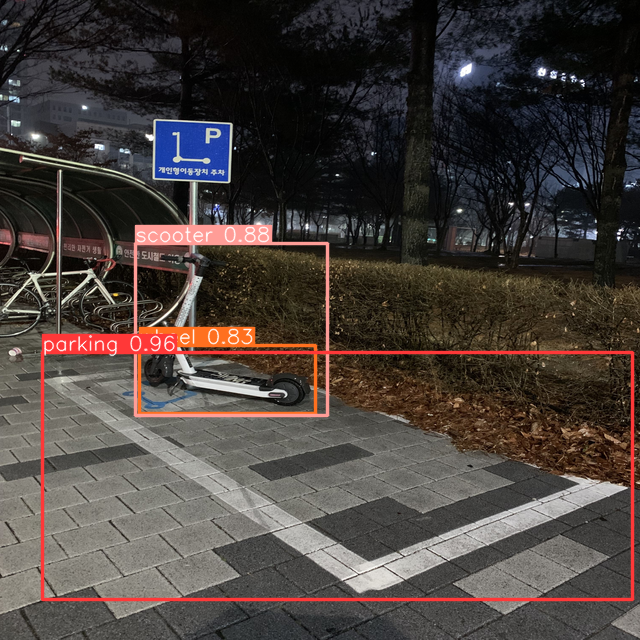

In [60]:
yolo_run_show(input_img)

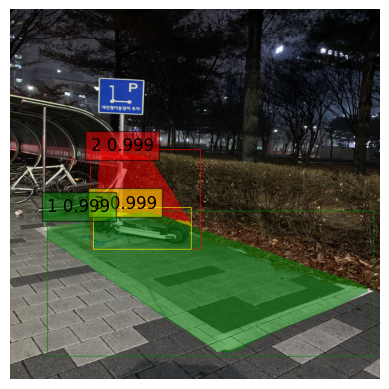

In [61]:
Mrcnn_run_show(device, input_img)

In [88]:
iou = calculate_segmentation_iou(yolo_result, mrcnn_result)

In [89]:
iou

0.8554650798621986